In [1]:
import os
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score)
from facenet_pytorch import InceptionResnetV1
from dataset import DroneFaceDataset, VGGFaceDataset, identity_SPLIT, get_embedding
from model import Embeddinghead, ArcFaceLoss

/home/shamma.yaqoob/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import os
import shutil
import random
from PIL import Image
import numpy as np
from torch.utils.data import Dataset 
import torchvision.transforms as transforms

sources = ["DL/open_data_set/photos_all_faces",
            "DL/open_data_set/portraits",
           "DL/open_data_set/trio_gp",
           "DL/open_data_set/trio_cam"]

destination = "combined_dataset"
os.makedirs(destination, exist_ok=True)

for source in sources:
    for filename in os.listdir(source):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            src_path = os.path.join(source, filename)
            dst_path = os.path.join(destination, filename)
            shutil.copy(src_path, dst_path)

print("all images combined successfully")



source = "combined_dataset"
destination = "prepared"

os.makedirs(destination, exist_ok=True)

for filename in os.listdir(source):
    if filename.lower().endswith((".jpg", ".png", "jpeg")):
        identity = filename[0].upper()
        identity_folder = os.path.join(destination, identity)
        os.makedirs(identity_folder, exist_ok=True)
        src_path = os.path.join(source, filename)
        dst_path = os.path.join(identity_folder, filename)
        shutil.move(src_path, dst_path)

print("Data split by identity")


source = "prepared"
base_split = "split" 

#splitting ids into training, validation, and testing
train_ids = ["A", "B", "C", "D", "E", "F", "G", "H"] #70% Training
val_ids = ["I"] #10% validation
test_ids = ["J", "K"] #20% testing


for split, ids in [("train", train_ids), ("validation", val_ids), ("test", test_ids)]:
    for identity in ids: 
        src = os.path.join(source, identity)
        dst = os.path.join(base_split, split, identity)
        os.makedirs(dst, exist_ok=True)
        for file in os.listdir(src):
            shutil.copy(os.path.join(src, file),
                        os.path.join(dst, file))
            
print("identity disjoint split completed")


FileNotFoundError: [Errno 2] No such file or directory: 'DL/open_data_set/photos_all_faces'

In [2]:
#settings 
batch_Size = 256
epochs = 30
lr = 1e-4 #learning rate 
threshold = 0.45 #above threshold:more confident, below  threshold=less confident

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("checkpoints", exist_ok=True)
print(f"Using: {device}")


Using: cuda


In [3]:
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

#dataset loading
train_set = DroneFaceDataset("split/train", augment=True)
validation_set = DroneFaceDataset("split/validation", augment=False)
test_set = DroneFaceDataset("split/test", augment=False)

num_classes = len(train_set.classes)
idx_to_class= {idx:name for name, idx in train_set.class_to_idx.items()}

#VGGFace2 dataset for phase1 
train_ids = sorted(os.listdir("VGGFace2/train"))
val_ids   = sorted(os.listdir("VGGFace2/val"))

# combines all ids for consistent labelling
all_ids    = sorted(set(train_ids) | set(val_ids))
all_id_map = {name: i for i, name in enumerate(all_ids)}

train_id_map = {name: all_id_map[name] for name in train_ids}
val_id_map   = {name: all_id_map[name] for name in val_ids}

num_vgg_classes = len(all_ids)

vgg_train = VGGFaceDataset("VGGFace2/train", train_ids, train_id_map, augment=True)
vgg_val   = VGGFaceDataset("VGGFace2/val",   val_ids,   val_id_map,   augment=False)

print(f"train identities: {len(train_ids)}")
print(f"val identities:   {len(val_ids)}")
print(f"total classes:    {num_vgg_classes}")
print(f"train images:     {len(vgg_train)}")
print(f"val images:       {len(vgg_val)}")


train identities: 480
val identities:   60
total classes:    540
train images:     176398
val images:       21295


**Extracting Embeddings**

In [ ]:
# if os.path.exists("cache_train_embeddings.npy"):
#     print("loading train embeddings")
#     train_embeddings = np.load("cache_train_embeddings.npy")
#     train_labels = np.load("cache_train_labels.npy")
# else: 
#     print("extracting")
#     train_embeddings, train_labels = [], []

#     for identity in train_set.classes:
#         folder= os.path.join("split", "train", identity)
#         for filename in os.listdir(folder):
#             if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
#                 continue
#             embedding = get_embedding(os.path.join(folder, filename))
#             if embedding is not None:
#                 train_embeddings.append(embedding)
#                 train_labels.append(train_set.class_to_idx[identity])
#             else:
#                 print("FAILED:", filename)
#         print("processing:", filename)
#     train_embeddings = np.array(train_embeddings)
#     train_labels = np.array(train_labels)
#     np.save("cache_train_embeddings.npy", train_embeddings)
#     np.save("cache_train_labels.npy", train_labels)

# if os.path.exists("cache_validation_embeddings.npy"):
#     print("loading validation embeddings")
#     validation_embeddings = np.load("cache_validation_embeddings.npy")
#     validation_labels = np.load("cache_validation_labels.npy")
# else: 
#     print("extracting")
#     validation_embeddings, validation_labels = [], []

#     for identity in validation_set.classes:
#         folder= os.path.join("split", "validation", identity)
#         for filename in os.listdir(folder):
#             if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
#                 continue
#             embedding = get_embedding(os.path.join(folder, filename))
#             if embedding is not None:
#                 validation_embeddings.append(embedding)
#                 validation_labels.append(validation_set.class_to_idx[identity])

# validation_embeddings = np.array(validation_embeddings)
# validation_labels = np.array(validation_labels)
# np.save("cache_validation_embeddings.npy", validation_embeddings)
# np.save("cache_validation_labels.npy", validation_labels)

# train_embeddings_tensor = torch.tensor(train_embeddings, dtype=torch.float32)
# train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
# validation_embeddings_tensor = torch.tensor(validation_embeddings, dtype=torch.float32)
# validation_labels_tensor = torch.tensor(validation_labels, dtype=torch.long)


loading train embeddings
loading validation embeddings


**Model Set up**

In [4]:
backbone = InceptionResnetV1(pretrained='vggface2').to(device)
#freezing all backbone layers
for param in backbone.parameters():
    param.requires_grad = False
#unfreezing last two blocks to adapt to drone footage
for param in backbone.block8.parameters():
    param.requires_grad = True
for param in backbone.avgpool_1a.parameters():
    param.requires_grad= True

head = Embeddinghead(input_dim=512, Embedding_dim=256).to(device)
arcface = ArcFaceLoss(in_features=256, num_classes=num_vgg_classes).to(device)


optimizer = torch.optim.Adam([{'params': filter(lambda p:p.requires_grad, backbone.parameters()), 'lr': 1e-5},
                              {'params': head.parameters(), 'lr': lr},
                              {'params': arcface.parameters(), 'lr': lr}])
optimizer.param_groups[2]['params'] = list(arcface.parameters())
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)



**Training Set up**

In [5]:
# embedding_loader = DataLoader(TensorDataset(train_embeddings_tensor, train_labels_tensor),
#                               batch_size=batch_Size,
#                               shuffle=True)

from torch.utils.data import random_split

train_size = int(0.9 * len(vgg_train))
val_size   = len(vgg_train) - train_size
vgg_train_split, vgg_val_split = random_split(vgg_train, [train_size, val_size])

train_loader = DataLoader(vgg_train_split, batch_size=batch_Size, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(vgg_val_split,   batch_size=batch_Size, shuffle=False, num_workers=8, pin_memory=True)

history = {'train_loss': [],
           'val_acc': []}

best_valacc = 0.0

for epoch in range(epochs):
    flag= " "
    backbone.train()
    head.train()
    arcface.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)
        optimizer.zero_grad()
        features= backbone(images)
        proj = head(features) 
        logits = arcface(proj, labels)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(backbone.parameters()) + list(head.parameters()) + list(arcface.parameters()), 5.0)
        optimizer.step()
        total_loss +=loss.item()
    scheduler.step()
    #building gallery
    backbone.eval(), head.eval()
    embeddings_gallery, labels_gallery = [], []
    with torch.no_grad():
        for images, labels in train_loader:
            features = backbone(images.to(device))
            embeddings_gallery.append(head(features).cpu())
            labels_gallery.append(labels)
    embeddings_gallery = F.normalize(torch.cat(embeddings_gallery), p=2, dim=1)
    labels_gallery = torch.cat(labels_gallery)

    #rank-1 validation
    val_embedding = []
    val_label = [] 
    with torch.no_grad():
        for images, labels in val_loader:
            features = backbone(images.to(device))
            val_embedding.append(head(features).cpu())
            val_label.append(labels)
            
    val_embedding = F.normalize(torch.cat(val_embedding), p=2, dim=1)
    val_label = torch.cat(val_label)

    rank1 = (labels_gallery[torch.mm(val_embedding, embeddings_gallery.T).argmax(dim=1)] == val_label).float().mean().item() * 100
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(rank1)
    
    if rank1 > best_valacc:
        best_valacc = rank1
        torch.save({'backbone': backbone.state_dict(),
                    'head': head.state_dict(),
                    'arcface': arcface.state_dict()}, "checkpoints/best_model.pth")
        flag= "saved"
    
    print(f"Epoch: {epoch+1} /{epochs}   Loss: {avg_loss:.4f}    Rank-1 {rank1:.2f} % {flag}")
    

Epoch: 1 /30   Loss: 37.8836    Rank-1 10.82 % saved
Epoch: 2 /30   Loss: 35.2096    Rank-1 17.89 % saved
Epoch: 3 /30   Loss: 34.5985    Rank-1 22.07 % saved
Epoch: 4 /30   Loss: 34.1952    Rank-1 22.77 % saved
Epoch: 5 /30   Loss: 33.8591    Rank-1 22.82 % saved
Epoch: 6 /30   Loss: 33.5773    Rank-1 19.62 %  
Epoch: 7 /30   Loss: 33.3192    Rank-1 27.94 % saved
Epoch: 8 /30   Loss: 33.0780    Rank-1 20.63 %  
Epoch: 9 /30   Loss: 32.8335    Rank-1 20.53 %  
Epoch: 10 /30   Loss: 32.6241    Rank-1 29.97 % saved
Epoch: 11 /30   Loss: 32.4138    Rank-1 20.08 %  
Epoch: 12 /30   Loss: 32.2378    Rank-1 23.02 %  
Epoch: 13 /30   Loss: 32.0753    Rank-1 28.11 %  
Epoch: 14 /30   Loss: 31.9049    Rank-1 29.17 %  
Epoch: 15 /30   Loss: 31.7280    Rank-1 32.28 % saved
Epoch: 16 /30   Loss: 31.5710    Rank-1 22.14 %  
Epoch: 17 /30   Loss: 31.4567    Rank-1 30.84 %  
Epoch: 18 /30   Loss: 31.3618    Rank-1 22.81 %  
Epoch: 19 /30   Loss: 31.2318    Rank-1 25.18 %  
Epoch: 20 /30   Loss: 31.18

In [6]:
checkpoint = torch.load("checkpoints/best_model.pth", map_location=device)
backbone.load_state_dict(checkpoint['backbone'])
head.load_state_dict(checkpoint['head'])


#reinitializing arcface for new identity count in drone face
arcface_drone = ArcFaceLoss(in_features=256, num_classes=num_classes, scale=32.0, margin=0.3).to(device)
#optimizer for fine-tuning
optimizer_ft = torch.optim.Adam([{'params': filter(lambda p:p.requires_grad, backbone.parameters()), 'lr': 1e-6},
                              {'params': head.parameters(), 'lr': 1e-4},
                              {'params': arcface_drone.parameters(), 'lr': 1e-4}])
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=20, eta_min=1e-7)



In [7]:
train_loader = DataLoader(train_set, batch_size=batch_Size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(validation_set, batch_size=batch_Size, shuffle=False, num_workers=4, pin_memory=True)

history_ft = {'train_loss': [],
           'val_acc': []}

best_Drone_Acc = 0.0

for epoch in range(20):
    flag= " "
    backbone.train()
    head.train()
    arcface_drone.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels=images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        proj = head(backbone(images)) 
        loss = F.cross_entropy(arcface_drone(proj, labels), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(backbone.parameters()) + list(head.parameters()) + list(arcface_drone.parameters()), 5.0)
        optimizer_ft.step()
        total_loss +=loss.item()
    scheduler_ft.step()
    #building gallery
    backbone.eval(), head.eval()
    embeddings_gallery, labels_gallery = [], []
    with torch.no_grad():
        for images, labels in train_loader:
            embeddings_gallery.append(head(backbone(images.to(device))).cpu())
            labels_gallery.append(labels)
    embeddings_gallery = F.normalize(torch.cat(embeddings_gallery), p=2, dim=1)
    labels_gallery = torch.cat(labels_gallery)

    #rank-1 validation
    val_embedding = []
    val_label = [] 
    with torch.no_grad():
        for images, labels in val_loader:
            val_embedding.append(head(backbone(images.to(device))).cpu())
            val_label.append(labels)
            
    val_embedding = F.normalize(torch.cat(val_embedding), p=2, dim=1)
    val_label = torch.cat(val_label)

    rank1 = (labels_gallery[torch.mm(val_embedding, embeddings_gallery.T).argmax(dim=1)] == val_label).float().mean().item() * 100
    avg_loss = total_loss / len(train_loader)
    history_ft['train_loss'].append(avg_loss)
    history_ft['val_acc'].append(rank1)
    
    if rank1 > best_Drone_Acc:
        best_Drone_Acc = rank1
        torch.save({'backbone': backbone.state_dict(),
                    'head': head.state_dict(),
                    'arcface': arcface_drone.state_dict()}, "checkpoints/best_drone_model.pth")
        flag= "saved"
    
    print(f"Epoch: {epoch+1} /20   Loss: {avg_loss:.4f}    Rank-1 {rank1:.2f} % {flag}")
    

Epoch: 1 /20   Loss: 12.5089    Rank-1 0.00 %  
Epoch: 2 /20   Loss: 11.1683    Rank-1 0.00 %  
Epoch: 3 /20   Loss: 10.1819    Rank-1 0.00 %  
Epoch: 4 /20   Loss: 9.7189    Rank-1 0.00 %  
Epoch: 5 /20   Loss: 8.6005    Rank-1 0.76 % saved
Epoch: 6 /20   Loss: 7.7501    Rank-1 0.00 %  
Epoch: 7 /20   Loss: 7.4221    Rank-1 3.05 % saved
Epoch: 8 /20   Loss: 6.8019    Rank-1 0.00 %  
Epoch: 9 /20   Loss: 6.3256    Rank-1 0.00 %  
Epoch: 10 /20   Loss: 6.1319    Rank-1 0.00 %  
Epoch: 11 /20   Loss: 5.8676    Rank-1 0.00 %  
Epoch: 12 /20   Loss: 5.3368    Rank-1 0.00 %  
Epoch: 13 /20   Loss: 5.1345    Rank-1 0.00 %  
Epoch: 14 /20   Loss: 5.1967    Rank-1 0.00 %  
Epoch: 15 /20   Loss: 5.6840    Rank-1 0.00 %  
Epoch: 16 /20   Loss: 5.3996    Rank-1 0.00 %  
Epoch: 17 /20   Loss: 5.0927    Rank-1 0.00 %  
Epoch: 18 /20   Loss: 4.9627    Rank-1 0.00 %  
Epoch: 19 /20   Loss: 5.1779    Rank-1 1.53 %  
Epoch: 20 /20   Loss: 5.2936    Rank-1 0.00 %  


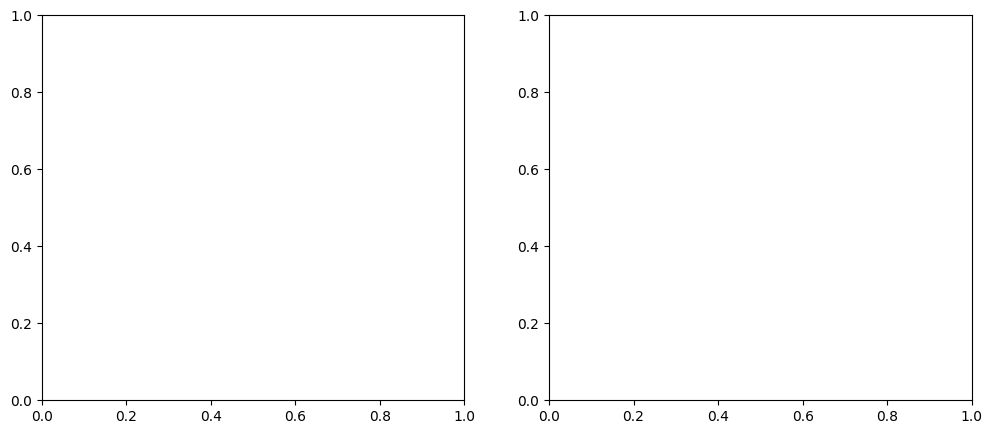

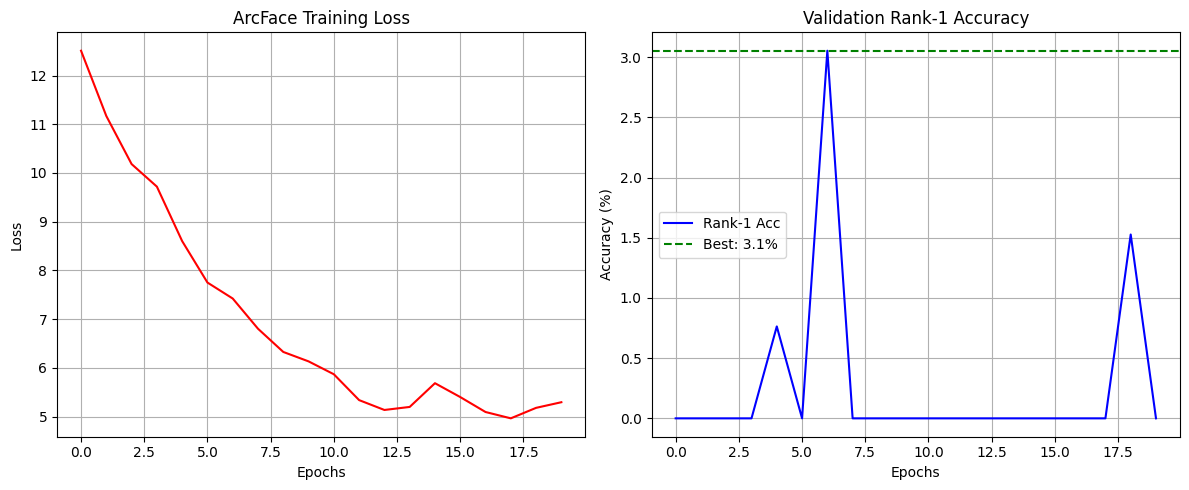

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_ft['train_loss'], 'r', label='Train Loss')
axes[0].set_title('ArcFace Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history_ft['val_acc'], 'b-', label='Rank-1 Acc')
axes[1].axhline(y=best_Drone_Acc, color='g', linestyle='--', label=f'Best: {best_Drone_Acc:.1f}%')
axes[1].set_title('Validation Rank-1 Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_progress.png')
plt.show()
plt.tight_layout()
plt.savefig('training_progress.png')

**Testing the model**

In [9]:
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, classification_report)


#loading the best saved model
checkpoint =torch.load("checkpoints/best_drone_model.pth", map_location=device)
backbone.load_state_dict(checkpoint['backbone'])
head.load_state_dict(checkpoint["head"])
backbone.eval()
head.eval()

test_loader= DataLoader(test_set, batch_size=batch_Size, shuffle=False, num_workers=4, pin_memory=True)

#building gallery from train set 
gallery_embedding, gallery_label = [], []

with torch.no_grad():
    for images, labels in train_loader:
         gallery_embedding.append(head(backbone(images.to(device))).cpu())
         gallery_label.append(labels)
gallery_embedding = F.normalize(torch.cat(gallery_embedding), p=2, dim=1)
gallery_label = torch.cat(gallery_label) 

#extracting test embeddings
test_embedding, test_label = [], [] 
with torch.no_grad():
    for images, labels in test_loader:
         test_embedding.append(head(backbone(images.to(device))).cpu())
         test_label.append(labels)
test_embedding = F.normalize(torch.cat(test_embedding), p=2, dim=1)
test_label = torch.cat(test_label) 

#rank-1 and rank-5 
similarity = torch.mm(test_embedding, gallery_embedding.T)
top5_idx = similarity.topk(5, dim=1).indices
rank1_preds = gallery_label[top5_idx[:, 0]].numpy()
query_np = test_label.numpy()

top1 = (rank1_preds == query_np).mean() * 100
top5 = (gallery_label[top5_idx].numpy() == query_np[:, None]).any(axis=1).mean() * 100

# for identity in test_set.classes: 
#     folder = os.path.join("split", "test", identity)
#     true_label = test_set.class_to_idx[identity]
#     files = sorted([f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png")) ])
#     mid = len(files) // 2
#     gallery_files = files[:mid]
#     query_files = files[mid:]

#     for filename in gallery_files:
#         embedding = get_embedding(os.path.join(folder, filename))
#         if embedding is None: 
#             continue
#         tensor = torch.tensor(embedding, dtype = torch.float32).unsqueeze(0).to(device)
#         with torch.no_grad():
#             proj = head(tensor).cpu().squeeze(0)
#         test_gal_embeddings.append(proj)
#         test_gal_labels.append(true_label)
#     for filename in query_files:
#         embedding = get_embedding(os.path.join(folder, filename))
#         if embedding is None: 
#             continue
#         tensor = torch.tensor(embedding, dtype = torch.float32).unsqueeze(0).to(device)
#         with torch.no_grad():
#             proj = head(tensor).cpu().squeeze(0)
#         test_query_embeddings.append(proj)
#         test_query_labels.append(true_label)
# test_gal_embeddings = torch.stack(test_gal_embeddings)
# test_gal_labels = torch.tensor(test_gal_labels)
# test_query_labels = torch.tensor(test_query_labels)

# top1 = top5 = total = 0
# rank1_preds = []
# for i in range(len(test_query_embeddings)):
#    similarities = F.cosine_similarity(test_query_embeddings[i].unsqueeze(0), test_gal_embeddings)

#    top5_idx = torch.topk(similarities, k=min(5, len(test_gal_embeddings))).indices
#    predicted_label = test_gal_labels[top5_idx[0]].item()
#    rank1_preds.append(predicted_label)

#    if predicted_label == test_query_labels[i].item():
#             top1 +=1
#    if test_query_labels[i].item() in [test_gal_labels[j].item() for j in top5_idx]:
#             top5 +=1
#    total +=1

print(f"Rank 1 Accuracy: {top1:.2f}%")
print(f"Rank 5 Accuracy: {top5:.2f}%"
      )

precision = precision_score(query_np, rank1_preds, average="macro", zero_division=0)
recall = recall_score(query_np, rank1_preds, average="macro", zero_division=0)
f1_Score = f1_score(query_np, rank1_preds, average="macro", zero_division=0)


print(f"Precision(macro): {precision:.4f}")
print(f"Recall(macro): {recall:.4f}")
print(f"F1 Score(macro): {f1_Score:.4f}")



Rank 1 Accuracy: 27.48%
Rank 5 Accuracy: 44.27%
Precision(macro): 0.0847
Recall(macro): 0.0785
F1 Score(macro): 0.0758


ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (2).

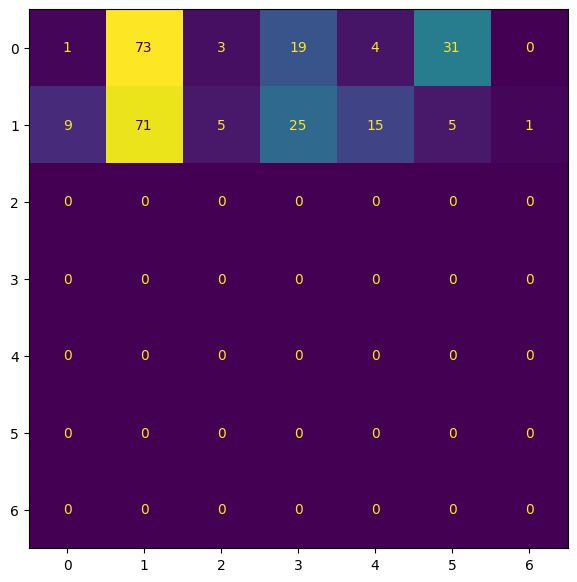

In [10]:
#Confusion Matrix
identity_names = test_set.classes
confusion_mat = confusion_matrix(query_np, rank1_preds)
fig, ax = plt.subplots(figsize=(8,7))
display = ConfusionMatrixDisplay(confusion_mat, display_labels=identity_names).plot(ax=ax, colorbar=False, xticks_rotation='vertical')

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("ConfusionMatrix.png", dpi=150)
plt.show()


#AUC Curve

y_true_pairs, y_scores_pairs = [] , []
for i in range(len(test_embedding)):
    for j in range(len(gallery_embedding)):
        y_true_pairs.append(int(test_label[i].item() == gallery_label[j].item()))
        y_scores_pairs.append(torch.dot(test_embedding[i], gallery_embedding[j]).item())
# auc = roc_auc_score(y_true_pairs, y_scores_pairs)

RocCurveDisplay.from_predictions(y_true_pairs, y_scores_pairs)
plt.title("ROC Curve: Query vs Gallery")
plt.savefig("roc_curve", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
report = classification_report(query_np, rank1_preds, target_names=identity_names, zero_division=0)
with open("classification_report.txt", "w") as f:
    f.write(report)


print(report)


              precision    recall  f1-score   support

           J       0.78      0.82      0.80        66
           K       0.81      0.77      0.79        66

    accuracy                           0.80       132
   macro avg       0.80      0.80      0.80       132
weighted avg       0.80      0.80      0.80       132



In [ ]:
#testing on a single image

def recognize_image(img_path):

    transform = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    img = transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        proj = F.normalize(head(backbone(img)).cpu(), p=2, dim=1)
    similarities = torch.mm(proj, gallery_embedding.T).squeeze(0)
    top5_idx = torch.topk(similarities, k=5).indices

    best_score = similarities[top5_idx[0]].item()
    best_name = idx_to_class[gallery_label[top5_idx[0]].item()]
    predicted = best_name if best_score >= threshold else "unknown"

    print(f"Predicted: {predicted} score: {best_score:.4f}")
    for i, idx in enumerate(top5_idx, 1):
        name = idx_to_class[gallery_label[idx].item()]
        score = similarities[idx].item()
        print(f"{i} {name} {score:.4f}")